In [1]:
from os import getenv
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

def md_display(s: str):
    """Just a shortcut for markdown display"""
    display(Markdown(s))

/var/folders/_7/ctdvqpn545g_11q0hy6r9n5h0000gn/T/ipykernel_19347/2713471351.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
USE_LOCAL_DATA = getenv("USE_LOCAL_DATA", 'false').lower() == 'true'
main_data = ("gut_taxonomic_table.csv"
             if USE_LOCAL_DATA else 'https://fmfi-compbio.github.io/viz/data/microbes/gut_taxonomic_table.csv' )
metadata_data = ("sample_data.csv"
                 if USE_LOCAL_DATA else 'https://fmfi-compbio.github.io/viz/data/microbes/sample_data.csv')

all_data_table = pd.read_csv(main_data, low_memory=False)
metadata_table = pd.read_csv(metadata_data, low_memory=False)

md_display(f"**Main Datatable:** {all_data_table.shape}")
md_display(f"**Metadata Datatable** {metadata_table.shape}")

**Main Datatable:** (4850, 4682)

**Metadata Datatable** (4850, 755)

In [3]:
md_display("# Alcohol data check")
columns = ['run_accession', 'attribute_alcohol_consumption', 'attribute_alcohol_frequency']
alco_metadata = metadata_table[columns]

# Alcohol data check

In [4]:
# Raw data tables have too many columns with too many data for this hypothesis check, skipping unneeded columns
columns = ['run_accession', 'attribute_alcohol_consumption', 'attribute_alcohol_frequency']
alco_metadata = metadata_table[columns]

In [5]:
# as the main data table has little bit different name for `run_accession`, 
# need to change it to 'run_accesion' to be able to merge with the metadata table
summarasized_bacteries_data = all_data_table.iloc[:, :1].copy()
summarasized_bacteries_data['run_accession'] = all_data_table['sample'].str.split('_').str[1]
summarasized_bacteries_data['count'] = all_data_table.iloc[:, 2:].sum(axis=1)
summarasized_bacteries_data['median'] = all_data_table.iloc[:, 2:].replace(0, pd.NA).median(axis=1)

display(summarasized_bacteries_data['median'])

0       27.0
1       23.0
2       36.0
3       27.5
4       34.5
        ... 
4845    34.0
4846    17.0
4847    24.0
4848    32.0
4849    33.5
Name: median, Length: 4850, dtype: object

In [6]:
# here comes the data and brief check for it
data = summarasized_bacteries_data.merge(alco_metadata, on='run_accession')
display(data)

,Unnamed: 0,run_accession,count,median,attribute_alcohol_consumption,attribute_alcohol_frequency
0,5122,ERR4371625,13995,27.0,Yes,Rarely (a few times/month)
1,5123,ERR4371626,21134,23.0,No,Never
2,5124,ERR4371627,16117,36.0,Yes,Occasionally (1-2 times/week)
3,5125,ERR4371628,15930,27.5,No,Never
4,5126,ERR4371629,15138,34.5,No,Never
...,...,...,...,...,...,...
4845,9967,ERR6177040,28583,34.0,No,Never
4846,9968,ERR6177041,20714,17.0,No,Never
4847,9969,ERR6177042,31653,24.0,No,Never
4848,9970,ERR6177043,16198,32.0,No,Never


In [7]:
# found out that there are multiple values for alcohol consumption columns, trying to find them all
md_display("## We have a little variation in representation for not available for alcohol consumption")
md_display("That is not that bad for us, as we going to use Yes / No only and for those we have clean representation in the data")

display(data.groupby('attribute_alcohol_consumption')['attribute_alcohol_consumption'].unique())


data2 = data.query('attribute_alcohol_consumption in ["Yes", "No"]')
display(data2.query('attribute_alcohol_consumption == "No" and attribute_alcohol_frequency != "Never"'))

md_display("## More detailed Yes answer has frequency of consumption, so we can go deeper in our analysis")
display(data2.query('attribute_alcohol_consumption == "Yes"').groupby('attribute_alcohol_frequency')['attribute_alcohol_frequency'].unique())

## We have a little variation in representation for not available for alcohol consumption

That is not that bad for us, as we going to use Yes / No only and for those we have clean representation in the data

attribute_alcohol_consumption
No                            [No]
Unspecified          [Unspecified]
Yes                          [Yes]
not applicable    [not applicable]
not collected      [not collected]
not provided        [not provided]
Name: attribute_alcohol_consumption, dtype: object

,Unnamed: 0,run_accession,count,median,attribute_alcohol_consumption,attribute_alcohol_frequency


## More detailed Yes answer has frequency of consumption, so we can go deeper in our analysis

attribute_alcohol_frequency
Daily                                                    [Daily]
Occasionally (1-2 times/week)    [Occasionally (1-2 times/week)]
Rarely (a few times/month)          [Rarely (a few times/month)]
Regularly (3-5 times/week)          [Regularly (3-5 times/week)]
Name: attribute_alcohol_frequency, dtype: object

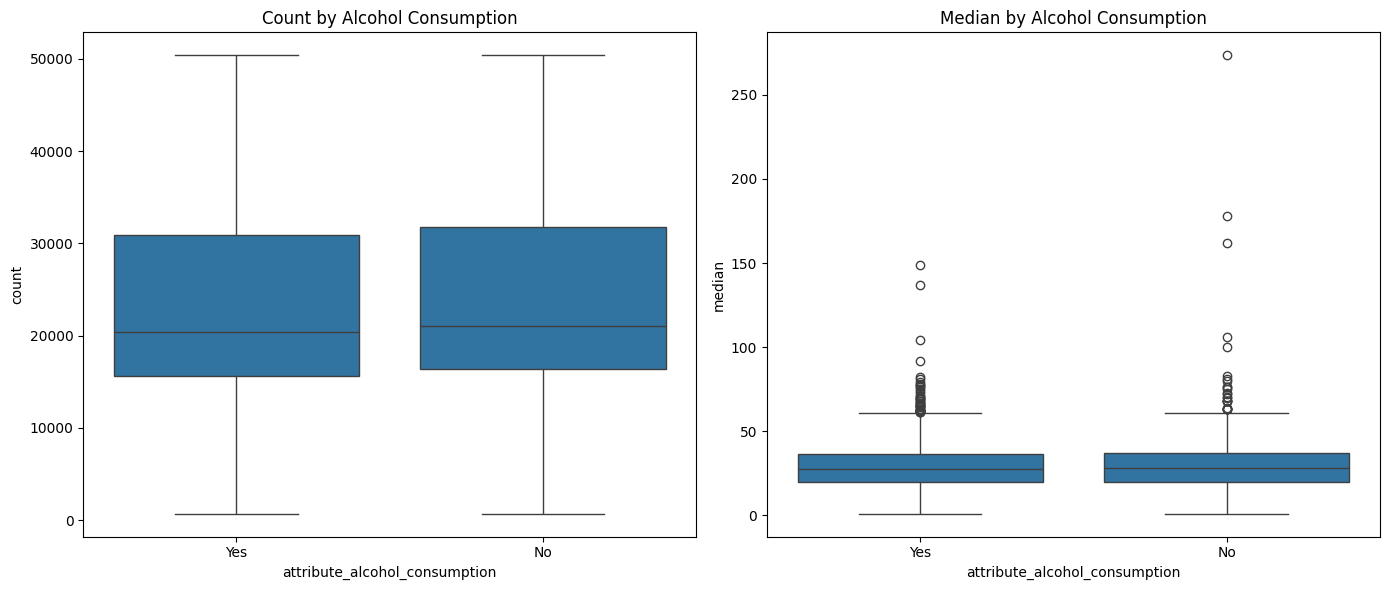

In [8]:
def outliers_cut(data: "Dataframe", count_col_name: str, lower: float = 0.05, upper: float = 0.95):
    """Removes data under the lower quantile and after the upper quantile"""
    lower_ = data[count_col_name].quantile(lower)
    upper_ = data[count_col_name].quantile(upper)
    data2 = data.copy()  # removing SettingWithCopyWarning
    data2[count_col_name] = data2[count_col_name].clip(lower=lower_, upper=upper_)
    return data2

# Cutting strange outliers
data2 = outliers_cut(data2, 'count')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=data2, x='attribute_alcohol_consumption', y='count', ax=axes[0])
axes[0].set_title('Count by Alcohol Consumption')

sns.boxplot(data=data2, x='attribute_alcohol_consumption', y='median', ax=axes[1])
axes[1].set_title('Median by Alcohol Consumption')

plt.tight_layout()
plt.show()

### Going deeper in analysis of those who consume alcohol

As we haven't found big variation in just Yes/No groups... So maybe there is something interesing with different frequency of the consumption

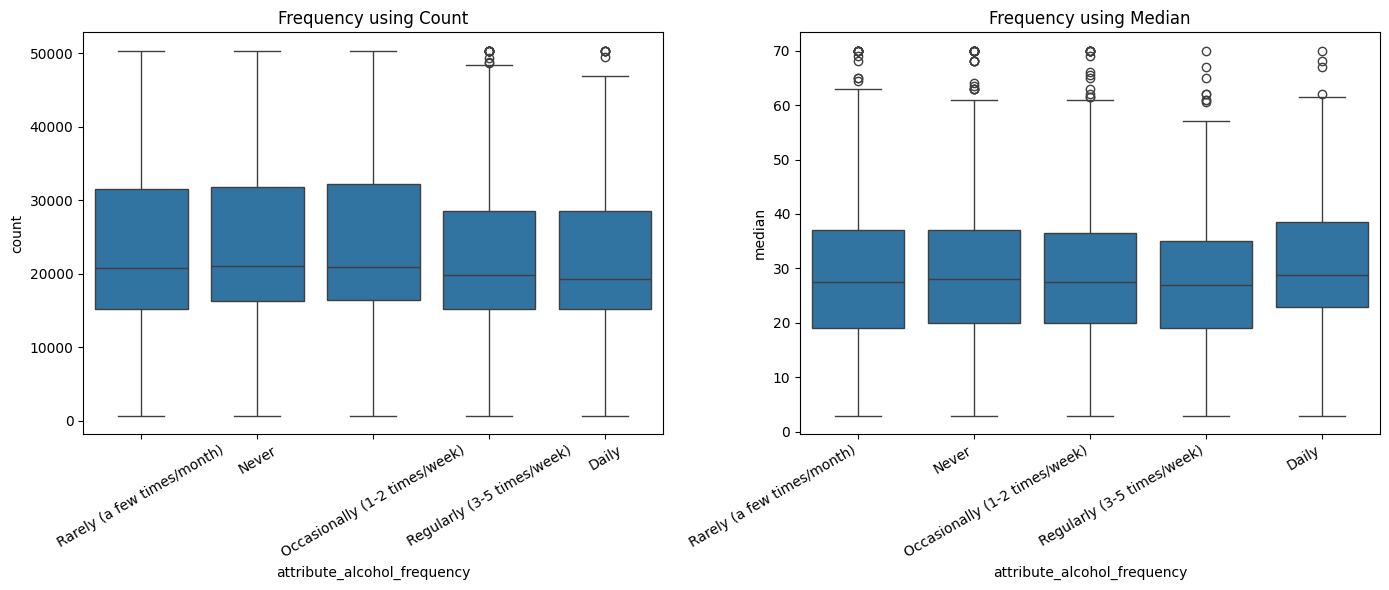

In [9]:
md_display("### Going deeper in analysis of those who consume alcohol")
md_display("As we haven't found big variation in just Yes/No groups... So maybe there is something interesing with different frequency of the consumption")

data3 = data.query('attribute_alcohol_consumption in ["Yes", "No"]')
data3 = outliers_cut(data3, 'count')
data3 = outliers_cut(data3, 'median', 0.01, 0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=data3, x='attribute_alcohol_frequency', y='count', ax=axes[0])
axes[0].set_title('Frequency using Count')
axes[0].tick_params(axis='x', rotation=30)


sns.boxplot(data=data3, x='attribute_alcohol_frequency', y='median', ax=axes[1])
axes[1].set_title('Frequency using Median')
axes[1].tick_params(axis='x', rotation=30)

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
pass

In [10]:
md_display("### Next thesis - diets and variations in bacteria")
md_display("We haven't found that alcohol probably does affect the microbes, so going to check if diet does")

strange_diet_names = ['attribute_pm_shared_who_nutritionistdietician','attribute_pm_lifestyle_change_how_change_in_diet_ie_taking_a_probiotic','attribute_diet','attribute_specialized_diet',]
all_diets = ['attribute_specialized_diet_i_do_not_eat_a_specialized_diet', 'attribute_specialized_diet_exclude_refined_sugars','attribute_specialized_diet_modified_paleo_diet','attribute_specialized_diet_exclude_dairy','attribute_specialized_diet_fodmap','attribute_specialized_diet_raw_food_diet','attribute_specialized_diet_kosher','attribute_lowgrain_diet_type','attribute_specialized_diet_other_restrictions_not_described_here','attribute_specialized_diet_halaal','attribute_specialized_diet_paleo_diet_or_primal_diet','attribute_specialized_diet_exclude_nightshades','attribute_specialized_diet_unspecified','attribute_specialized_diet_paleodiet_or_primal_diet', 'attribute_specialized_diet_westenprice_or_lowgrain_low_processed_food_diet']


# going to check data about diets
display(metadata_table.groupby('attribute_specialized_diet_exclude_refined_sugars')['attribute_specialized_diet_exclude_refined_sugars'].unique())

# Shows that we have a lot of different answers for Yes / No / Uknown options
# for diet in all_diets:
#     display(Markdown(f"**{diet}**"))
#     res = metadata_table.groupby(diet)[diet].unique()
#     display(res)
#     display(type(res.iloc[0]))

### Next thesis - diets and variations in bacteria

We haven't found that alcohol probably does affect the microbes, so going to check if diet does

attribute_specialized_diet_exclude_refined_sugars
FALSE                    [FALSE]
No                          [No]
TRUE                      [TRUE]
Unknown                [Unknown]
Unspecified        [Unspecified]
Yes                        [Yes]
false                    [false]
not collected    [not collected]
true                      [true]
Name: attribute_specialized_diet_exclude_refined_sugars, dtype: object

In [11]:
# Fixing triplication of wester / low grain diet...
metadata_table['attribute_specialized_diet_westenprice_or_lowgrain_low_processed_food_diet'] = (
    metadata_table['attribute_specialized_diet_westenprice_or_other_lowgrain_low_processed_food_diet']
        .fillna(metadata_table['attribute_specialized_diet_weston_price_or_other_low_grain_low_processed_food_diet'])
        .fillna(metadata_table['attribute_specialized_diet_westenprice_or_other_lowgrain_low_processed_fo'])
)            

extra_diets_cols = ('attribute_diet_type', )

# We're going to change to one representation of Python's True / False + None for whole Datazoo of possible Yes / No /Uknown options used
# "False", "FALSE", "false", "No", "no", "NO" -> False

fixes = [[{"true", "yes"}, "yes"], 
         [{"false", "no"}, "no"], 
         [{"unknown", "unspecified", "not collected", "not provided", "not applicable ", "None"}, "unknown"]
        ]

try:
    for diet in all_diets:
        for fix in fixes:
            mask = (
                metadata_table[diet]
                .astype(str)
                .str.lower()
                .isin(fix[0])
            )
    
            metadata_table.loc[mask, diet] = fix[1]
except Exception as e:
    display(e, mask, diet, fix)

In [15]:
# All good now
display(Markdown(f"**{diet}**"))
res = metadata_table.groupby(all_diets[0], dropna=False)[diet].unique()
display(res)
display(type(res.iloc[0]))

**attribute_specialized_diet_westenprice_or_lowgrain_low_processed_food_diet**

attribute_specialized_diet_i_do_not_eat_a_specialized_diet
no         [no, unknown, LabControl test, yes, nan]
unknown                              [unknown, nan]
yes        [no, unknown, LabControl test, yes, nan]
NaN                                           [nan]
Name: attribute_specialized_diet_westenprice_or_lowgrain_low_processed_food_diet, dtype: object

numpy.ndarray